In this notebook, we consider the results for the rational quadratic correlation function.

In [6]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm, TwoSlopeNorm
import matplotlib.ticker as mticker
import numpy as np
import torch
import scipy
import scipy.linalg
import gaussian_crossings as gc

In [2]:
# Set simulation parameters.
T = 100.0    # Total simulation time (e.g., 10 time units)
alpha = 3.0  # Shape parameter controlling the relative weighting of different scales
sigma = 1.0 # Standard deviation (amplitude) of the process

In [4]:
num_points_taus = 50
taus = torch.linspace(0.01, 1.0, num_points_taus)

num_points_zeta = 50
zeta = torch.linspace(0.0, 3.0, num_points_zeta)

mean_rates = torch.zeros(num_points_taus, num_points_zeta)
fano_factors = torch.zeros(num_points_taus, num_points_zeta)

In [5]:
for i in range(num_points_taus):
    for j in range(num_points_zeta):
        u = zeta[j] * sigma
        tau = taus[i]
        model = gc.GaussianUpCrossingsDimless(r_func=gc.r_rational_quadratic, u=u, tau=tau, sigma=sigma, alpha=alpha)
        mean_rates[i, j] = model.upcrossing_mean_rate()
        fano_factors[i, j] = model.upcrossing_fano_factor_CLT(epsilon_left=1e-2, epsilon_right=1e-5)

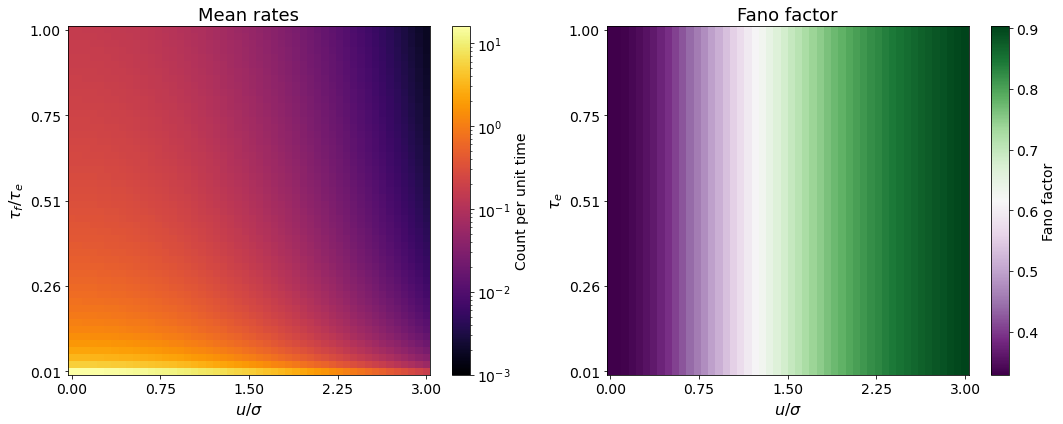

In [12]:
# If necessary, ensure that taus is increasing:
if taus[0] > taus[-1]:
    taus = np.flipud(taus)
    mean_rates = np.flipud(mean_rates)
    fano_factors = np.flipud(fano_factors)

# -----------------------
# Helper: Compute cell edges for arbitrary spacing
# -----------------------
def compute_edges(arr):
    """
    Given a 1D array of cell centers, compute cell edges.
    """
    edges = np.empty(len(arr) + 1)
    # Interior edges: midpoints
    edges[1:-1] = (arr[:-1] + arr[1:]) / 2.0
    # Extrapolate first and last edge
    edges[0] = arr[0] - (arr[1] - arr[0]) / 2.0
    edges[-1] = arr[-1] + (arr[-1] - arr[-2]) / 2.0
    return edges

# Compute cell edges from the center values
zeta_edges = compute_edges(zeta)
taus_edges = compute_edges(taus)

# -----------------------
# Plotting parameters
# -----------------------
cmap_mean = 'inferno'
cmap_fano = 'PRGn'
label_fontsize = 16
tick_fontsize = 14
title_fontsize = 18
cbar_labelsize = 14

# Number of ticks to display on each axis (independent of underlying spacing)
num_ticks = 5
x_ticks = np.linspace(zeta.min(), zeta.max(), num_ticks)
y_ticks = np.linspace(taus.min(), taus.max(), num_ticks)

# -----------------------
# Create the figure and subplots

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ---- Left subplot: Mean Rates with Linear Scale ----
# Set a small threshold epsilon for the lower bound (adjust as needed)
epsilon = 1e-3
# Clip the data so that no value is below epsilon
adjusted_mean_rates = np.clip(mean_rates, epsilon, None)
# Set up LogNorm with vmin set to epsilon and vmax as the maximum of the adjusted data
log_norm = LogNorm(vmin=epsilon, vmax=adjusted_mean_rates.max())

pc0 = axes[0].pcolormesh(zeta_edges, taus_edges, adjusted_mean_rates, shading='auto',
                         cmap=cmap_mean, norm=log_norm)
cbar0 = fig.colorbar(pc0, ax=axes[0])
cbar0.set_label("Count per unit time", fontsize=cbar_labelsize)
cbar0.ax.tick_params(labelsize=tick_fontsize)

axes[0].set_xlabel(r'$u/\sigma$', fontsize=label_fontsize)
axes[0].set_ylabel(r'$\tau_f/\tau_e$', fontsize=label_fontsize)
axes[0].set_title('Mean rates', fontsize=title_fontsize)
axes[0].set_xticks(x_ticks)
axes[0].set_yticks(y_ticks)
axes[0].set_xticklabels([f"{val:.2f}" for val in x_ticks], fontsize=tick_fontsize)
axes[0].set_yticklabels([f"{val:.2f}" for val in y_ticks], fontsize=tick_fontsize)

# -----------------------
# Right subplot: Fano Factors
# -----------------------
# Plot Fano factors on a linear scale
pc1 = axes[1].pcolormesh(zeta_edges, taus_edges, fano_factors, shading='auto',
                         cmap=cmap_fano)
cbar1 = fig.colorbar(pc1, ax=axes[1])
cbar1.set_label("Fano factor", fontsize=cbar_labelsize)
cbar1.ax.tick_params(labelsize=tick_fontsize)

axes[1].set_xlabel(r'$u/\sigma$', fontsize=label_fontsize)
axes[1].set_ylabel(r'$\tau_e$', fontsize=label_fontsize)
axes[1].set_title('Fano factor', fontsize=title_fontsize)
axes[1].set_xticks(x_ticks)
axes[1].set_yticks(y_ticks)
axes[1].set_xticklabels([f"{val:.2f}" for val in x_ticks], fontsize=tick_fontsize)
axes[1].set_yticklabels([f"{val:.2f}" for val in y_ticks], fontsize=tick_fontsize)


plt.tight_layout()
plt.show()

In [6]:
model = gc.GaussianUpCrossings(r_func=gc.r_rational_quadratic, u=1.0, tau=0.01, sigma=sigma, alpha=alpha)
print(model.upcrossing_fano_factor_CLT(epsilon_left=1e-2, epsilon_right=1e-5))

tensor([0.5625])
